# Protein graphs + NetworkX: from domain shuffling to codon design

This notebook demonstrates a realistic bioinformatics workflow that bridges
Gen's graph database and Python's scientific ecosystem:

1. **Load** a protein domain-shuffling library into Gen
2. **Export** to NetworkX and run graph algorithms (centrality, path enumeration,
   topological structure)
3. **Visualise** the protein graph with force-directed and multipartite layouts
4. **Back-translate** a protein sequence into a codon-choice graph — every synonymous
   codon at each position becomes a node; consecutive positions connect all-to-all
5. **Analyse** the codon graph with NetworkX statistics
6. **Import** the codon graph back into Gen and plot it with the interactive widget

### Why the codon graph is interesting

The genetic code is degenerate: most amino acids are encoded by 2–6 synonymous codons.
If you represent every codon option as a node and connect adjacent positions
all-to-all, you get a DAG whose paths are exactly the set of all DNA sequences that
encode the same protein.  The number of paths equals the product of per-position
codon counts — a combinatorially large space compactly captured in a small graph.

## 1. Setup — load the protein shuffling library

In [1]:
import math
import pathlib
import tempfile

import gen
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from gen import Block, EndBlock, StartBlock

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120})

REPO_ROOT = pathlib.Path(gen.__file__).parents[3]
parts  = REPO_ROOT / "fixtures" / "protein_segments.fa"
design = REPO_ROOT / "fixtures" / "protein_layout.csv"

assert parts.exists(),  f"Fixture not found: {parts}"
assert design.exists(), f"Fixture not found: {design}"

repo = gen.Repository(str(pathlib.Path(tempfile.mkdtemp(prefix="gen-nx-"))))
repo.import_library_files('shuffling', str(parts), str(design))

bgs = repo.get_block_groups()
bg  = bgs[0]
print(f"Imported {len(bgs)} block group(s)")
print(bg)

Imported 1 block group(s)
BlockGroup(0392b64b72c294f71a2885c7c53c0417ee94f9cdaff9bada0db449b5d7df453d, default, reference, shuffling)


## 2. Export to NetworkX and inspect the graph

`to_networkx()` returns a `nx.DiGraph` whose node keys are `Block` objects.
Sentinel `StartBlock` / `EndBlock` nodes mark the graph boundaries.

In [2]:
G = bg.to_networkx()

def content_nodes(graph):
    return [n for n in graph.nodes() if not isinstance(n, (StartBlock, EndBlock))]

cn = content_nodes(G)
start_node = next(n for n in G.nodes() if isinstance(n, StartBlock))
end_node   = next(n for n in G.nodes() if isinstance(n, EndBlock))

print(f"Total nodes (incl. sentinels) : {G.number_of_nodes()}")
print(f"Content nodes                 : {len(cn)}")
print(f"Edges                         : {G.number_of_edges()}")
print()

for node in cn[:3]:
    length = node.sequence_end - node.sequence_start
    seq_preview = (node.sequence[:30] + '…') if node.sequence else '<no sequence>'
    print(f"  id[:16] : {str(node.node_id)[:16]}…")
    print(f"  seq[:30]: {seq_preview}")
    print(f"  length  : {length} residues")
    print()


Total nodes (incl. sentinels) : 26
Content nodes                 : 24
Edges                         : 69

  id[:16] : 185f1c2fe1ac839a…
  seq[:30]: EKRFDKNLGKGLQKVREFGGDGLFTSWTHE…
  length  : 58 residues

  id[:16] : 7840d8c88123a7a0…
  seq[:30]: ESRFDKNLSQALKFVRDFAGDGLFTSWTHE…
  length  : 58 residues

  id[:16] : 806d423192854ac2…
  seq[:30]: APAFSLYAKEDTVLGGEYPLEKGDELMVLI…
  length  : 76 residues



## 3. Graph algorithms

### 3a. DAG structure and topological generations

Domain-shuffling libraries have a strict positional structure: every protein is a
linear chain of segments drawn from the same fixed set of domain positions.
`topological_generations` exposes these positions as layers.

In [3]:
print("Is directed acyclic graph:", nx.is_directed_acyclic_graph(G))

all_gens = list(nx.topological_generations(G))
content_gens = [
    [n for n in layer if not isinstance(n, (StartBlock, EndBlock))]
    for layer in all_gens
]
content_gens = [layer for layer in content_gens if layer]

print(f"\nDomain positions (topological layers): {len(content_gens)}")
for i, layer in enumerate(content_gens):
    lengths = [n.sequence_end - n.sequence_start for n in layer]
    print(f"  pos {i}: {len(layer)} variant(s), lengths {lengths}")

Is directed acyclic graph: True

Domain positions (topological layers): 9
  pos 0: 3 variant(s), lengths [65, 64, 65]
  pos 1: 3 variant(s), lengths [58, 58, 58]
  pos 2: 3 variant(s), lengths [44, 44, 44]
  pos 3: 3 variant(s), lengths [50, 50, 50]
  pos 4: 3 variant(s), lengths [53, 52, 53]
  pos 5: 3 variant(s), lengths [60, 60, 60]
  pos 6: 3 variant(s), lengths [76, 76, 76]
  pos 7: 3 variant(s), lengths [645, 655, 648]
  pos 8: 1 variant(s), lengths [0]


### 3b. Path enumeration

The library imports a **combinatorial** block group: every combination of one segment
per domain position is a valid path, not just the three explicitly defined proteins.
With 3 variants per position and 8 positions the total is 3⁸ = 6 561 paths.
Each path spells out a complete chimeric protein sequence.

In [4]:
paths = list(nx.all_simple_paths(G, start_node, end_node))
print(f"Complete protein variants : {len(paths):,}")
print(f"Nodes per path (incl. sentinels): {len(paths[0])}")

# Reconstruct one full-length protein sequence from the first path.
# Guard node.sequence against None — some segment nodes may carry no
# sequence payload when stored as coordinate-only references in the DB.
first_protein = "".join(
    node.sequence
    for node in paths[0]
    if not isinstance(node, (StartBlock, EndBlock)) and node.sequence is not None
)
print(f"\nFirst chimeric protein ({len(first_protein)} aa):")
print(first_protein)


Complete protein variants : 6,561
Nodes per path (incl. sentinels): 10

First chimeric protein (1051 aa):
MKQASAIPQPKTYGPLKNLPHLEKEQLSQSLWRIADELGPIFRFDFPGVSSVFVSGHNLVAEVCDEKRFDKNLGKGLQKVREFGGDGLFTSWTHEPNWQKAHRILLPSFSQKAMKGYHSMMLDIATQLIQKWSRLNPNEEIDVADDMTRLTLDTIGLCGFNYRFNSFYRETPHPFINSMVRALDEAMHQMQRLDVQDKLMVRTKRQFRYDIQTMFSLVDRMIAERKANPDENIKDLLSLMLYAKDPVTGETLDDENIRYQIITFLIAGHETTSGLLSFALYFLVKNPHVLQKAAEEAARVLVDPVPSYKQVKQLKYVGMVLNEALRLWPTAPAFSLYAKEDTVLGGEYPLEKGDELMVLIPQLHRDKTIWGDDVEEFRPERFENPSAIPQHAFKPFGNGQRACIGQQFALHEATLVLGMMLKHFDFEDHTNYELDIKETLTLKPEGFVVKAKSKKIPLGGIPSPSTEQSAKKVRKKAENAHNTPLLVLYGSNMGTAEGTARDLADIAMSKGFAPQVATLDSHAGNLPREGAVLIVTASYNGHPPDNAKQFVDWLDQASADEVKGVRYSVFGCGDKNWATTYQKVPAFIDETLAAKGAENIADRGEADASDDFEGTYEEWREHMWSDVAAYFNLDIENSEDNKSTLSLQFVDSAADMPLAKMHGAFSTNVVASKELQQPGSARSTRHLEIELPKEASYQEGDHLGVIPRNYEGIVNRVTARFGLDASQQIRLEAEEEKLAHLPLAKTVSVEELLQYVELQDPVTRTQLRAMAAKTVCPPHKVELEALLEKQAYKEQVLAKRLTMLELLEKYPACEMKFSEFIALLPSIRPRYYSISSSPRVDEKQASITVSVVSGEAWSGYGEYKGIASNYLAELQEGDTITCFISTPQSEFTLP

### 3c. Degree centrality

Degree centrality in the undirected projection shows which segment nodes are most
connected.  Segments at the domain boundaries (positions 0 and 7) attach to the
sentinels, giving them an extra edge.

In [5]:
dc = nx.degree_centrality(G)
# key=lambda avoids comparing Block objects when scores are tied
ranked = sorted([(dc[n], n) for n in cn], key=lambda x: x[0], reverse=True)

print("Content nodes ranked by degree centrality:")
for score, node in ranked[:6]:
    domain_pos = next(
        j for j, layer in enumerate(content_gens) if node in layer
    )
    seq_label = (node.sequence[:12] + '…') if node.sequence else '<no seq>'
    print(f"  centrality={score:.4f}  domain_pos={domain_pos}  seq={seq_label}")


Content nodes ranked by degree centrality:
  centrality=0.2400  domain_pos=1  seq=EKRFDKNLGKGL…
  centrality=0.2400  domain_pos=1  seq=ESRFDKNLSQAL…
  centrality=0.2400  domain_pos=6  seq=APAFSLYAKEDT…
  centrality=0.2400  domain_pos=5  seq=TTSGLLSFALYF…
  centrality=0.2400  domain_pos=5  seq=TTSGLLSFAIYC…
  centrality=0.2400  domain_pos=4  seq=VDRMIAERKANP…


## 4. Visualisation

### 4a. Multipartite layout — domain positions as columns

Assign each node a `subset` equal to its domain position; `multipartite_layout`
places nodes in vertical lanes.

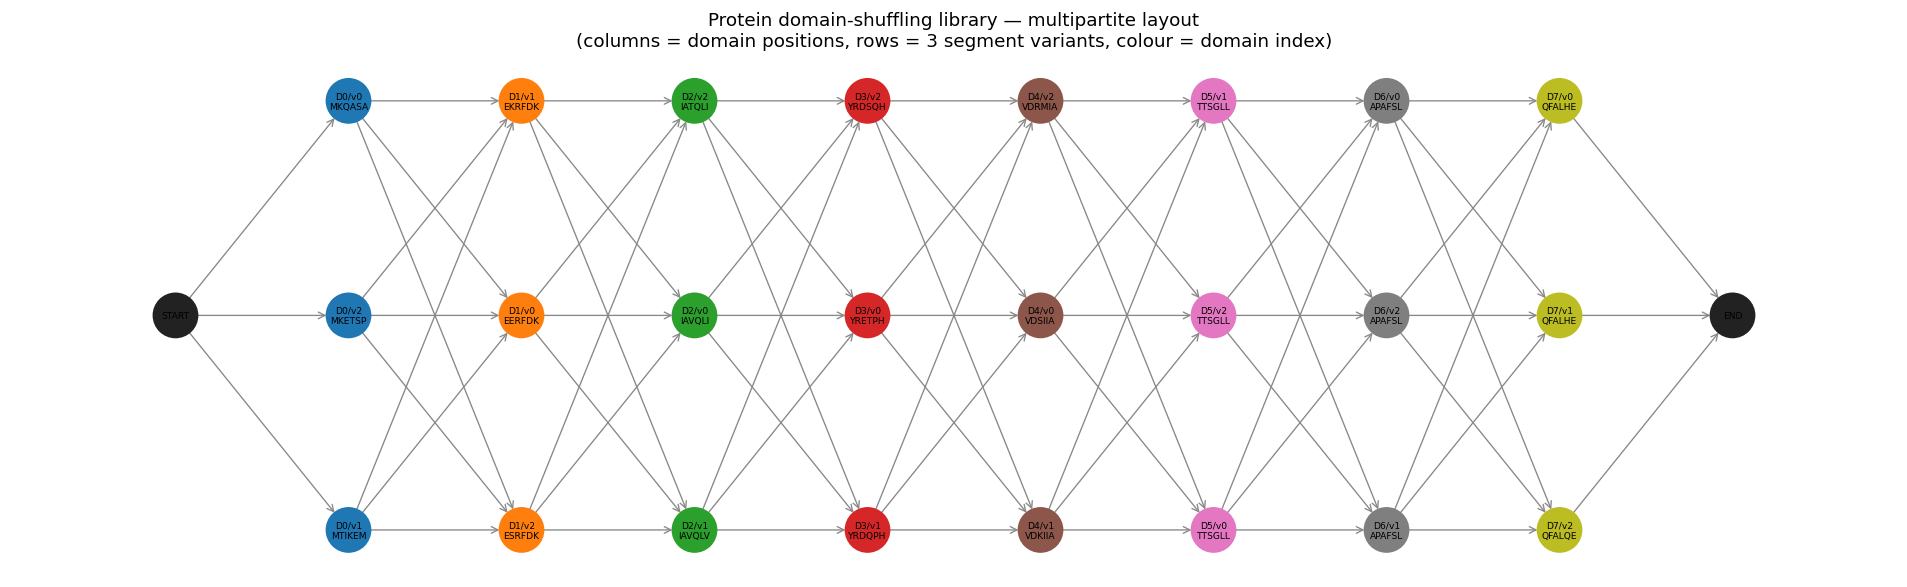

In [6]:
for i, layer in enumerate(content_gens):
    for node in layer:
        G.nodes[node]['subset'] = i
G.nodes[start_node]['subset'] = -1
G.nodes[end_node]['subset']   = len(content_gens)

pos = nx.multipartite_layout(G, subset_key='subset', align='vertical')

cmap = plt.cm.tab10
node_colours = []
for node in G.nodes():
    if isinstance(node, (StartBlock, EndBlock)):
        node_colours.append('#222222')
    else:
        s = G.nodes[node]['subset']
        node_colours.append(cmap(s / max(1, len(content_gens) - 1)))

labels = {}
for i, layer in enumerate(content_gens):
    for j, node in enumerate(layer):
        seq_snip = node.sequence[:6] if node.sequence else '??'
        labels[node] = f"D{i}/v{j}\n{seq_snip}"
labels[start_node] = 'START'
labels[end_node]   = 'END'

fig, ax = plt.subplots(figsize=(16, 5))
nx.draw(
    G, pos=pos, ax=ax,
    labels=labels, node_color=node_colours,
    node_size=700, font_size=5.5,
    arrows=True, arrowstyle='->', arrowsize=10,
    edge_color='#888888', width=0.8,
)
ax.set_title(
    "Protein domain-shuffling library — multipartite layout\n"
    "(columns = domain positions, rows = 3 segment variants, colour = domain index)",
    fontsize=11,
)
plt.tight_layout()
plt.show()


### 4b. Force-directed layout (spring)

Without positional constraints, the spring layout pulls the three independent chains
apart and groups segments by their shared neighbours.

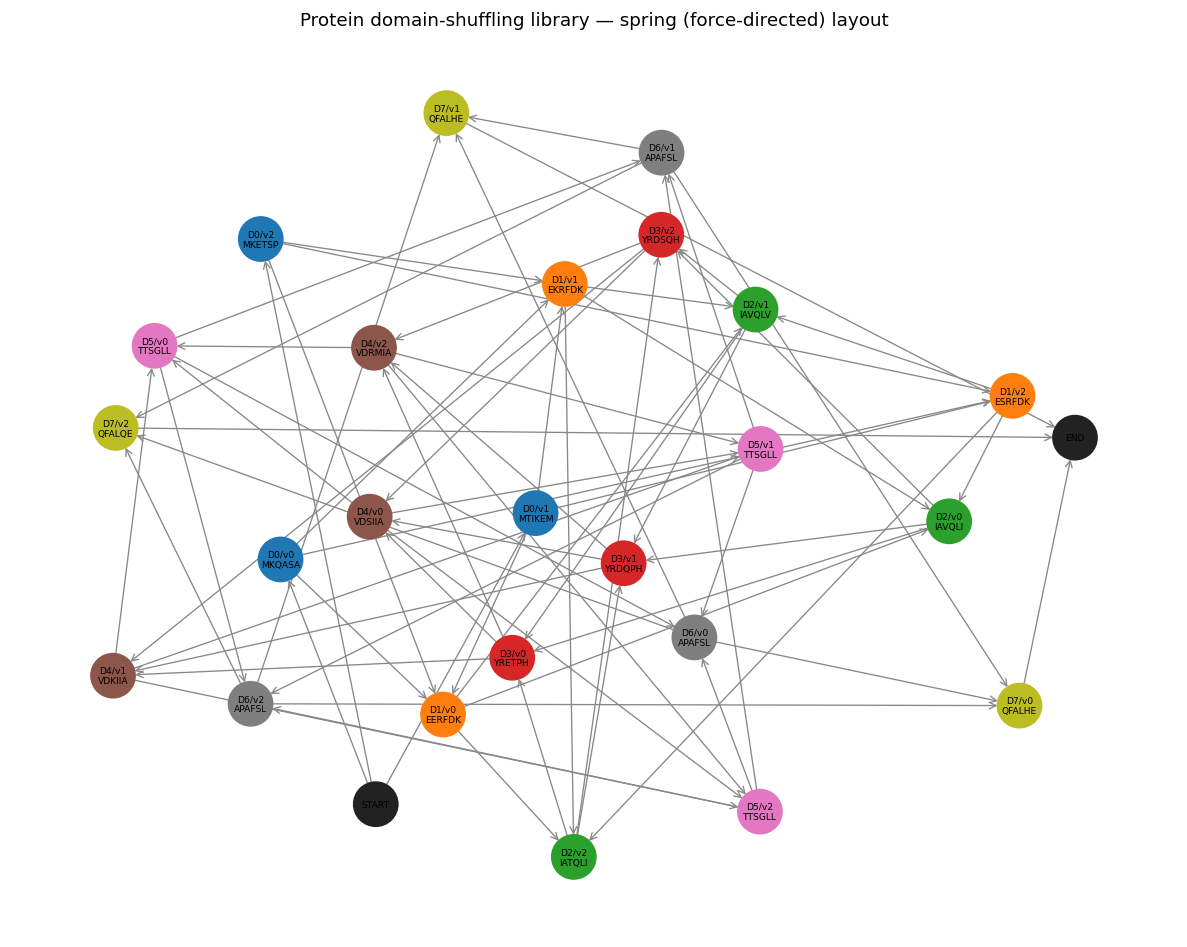

In [7]:
spring_pos = nx.spring_layout(G, seed=42, k=1.5)

fig, ax = plt.subplots(figsize=(10, 8))
nx.draw(
    G, pos=spring_pos, ax=ax,
    labels=labels, node_color=node_colours,
    node_size=700, font_size=5.5,
    arrows=True, arrowstyle='->', arrowsize=10,
    edge_color='#888888', width=0.8,
)
ax.set_title(
    "Protein domain-shuffling library — spring (force-directed) layout",
    fontsize=11,
)
plt.tight_layout()
plt.show()

## 5. Codon back-translation graph

We now reverse-translate a protein sequence into a **codon graph**.  The construction
rule is:

- Each amino acid position maps to one `Block` per synonymous codon.
- Every block at position *i* connects to every block at position *i+1* (all-to-all).
- **Fresh `Block` objects** (no `node_id` argument) are used at every position so each
  codon node gets a unique UUID-7 identity.  Reusing a `node_id` across positions
  would create cycles in the graph.

The result is a DAG; each path through it is one complete synonymous DNA sequence.

In [8]:
# Standard genetic code — DNA coding strand
CODON_TABLE: dict[str, list[str]] = {
    'A': ['GCT', 'GCC', 'GCA', 'GCG'],
    'C': ['TGT', 'TGC'],
    'D': ['GAT', 'GAC'],
    'E': ['GAA', 'GAG'],
    'F': ['TTT', 'TTC'],
    'G': ['GGT', 'GGC', 'GGA', 'GGG'],
    'H': ['CAT', 'CAC'],
    'I': ['ATT', 'ATC', 'ATA'],
    'K': ['AAA', 'AAG'],
    'L': ['TTA', 'TTG', 'CTT', 'CTC', 'CTA', 'CTG'],
    'M': ['ATG'],
    'N': ['AAT', 'AAC'],
    'P': ['CCT', 'CCC', 'CCA', 'CCG'],
    'Q': ['CAA', 'CAG'],
    'R': ['CGT', 'CGC', 'CGA', 'CGG', 'AGA', 'AGG'],
    'S': ['TCT', 'TCC', 'TCA', 'TCG', 'AGT', 'AGC'],
    'T': ['ACT', 'ACC', 'ACA', 'ACG'],
    'V': ['GTT', 'GTC', 'GTA', 'GTG'],
    'W': ['TGG'],
    'Y': ['TAT', 'TAC'],
    '*': ['TAA', 'TAG', 'TGA'],
}

# Use the first 12 residues of the first protein in the library
aa_seq = first_protein[:12]
print(f"Amino acid sequence ({len(aa_seq)} residues): {aa_seq}")
print()
print("Codon options per position:")
for i, aa in enumerate(aa_seq):
    codons = CODON_TABLE.get(aa, ['NNN'])
    print(f"  pos {i:2d}  {aa}  →  {codons}")

Amino acid sequence (12 residues): MKQASAIPQPKT

Codon options per position:
  pos  0  M  →  ['ATG']
  pos  1  K  →  ['AAA', 'AAG']
  pos  2  Q  →  ['CAA', 'CAG']
  pos  3  A  →  ['GCT', 'GCC', 'GCA', 'GCG']
  pos  4  S  →  ['TCT', 'TCC', 'TCA', 'TCG', 'AGT', 'AGC']
  pos  5  A  →  ['GCT', 'GCC', 'GCA', 'GCG']
  pos  6  I  →  ['ATT', 'ATC', 'ATA']
  pos  7  P  →  ['CCT', 'CCC', 'CCA', 'CCG']
  pos  8  Q  →  ['CAA', 'CAG']
  pos  9  P  →  ['CCT', 'CCC', 'CCA', 'CCG']
  pos 10  K  →  ['AAA', 'AAG']
  pos 11  T  →  ['ACT', 'ACC', 'ACA', 'ACG']


In [9]:
# Build the codon DAG
# pos_nodes[i] = list of fresh Block objects for amino acid position i
# Fresh Block() = no node_id → new UUID-7; avoids cycles from ID reuse
pos_nodes: list[list[Block]] = []
for i, aa in enumerate(aa_seq):
    codons = CODON_TABLE.get(aa, ['NNN'])
    pos_nodes.append([Block(codon) for codon in codons])

G_codon = nx.DiGraph()

# Register nodes with their position as the multipartite subset attribute
for i, layer in enumerate(pos_nodes):
    for block in layer:
        G_codon.add_node(block, subset=i, aa=aa_seq[i], pos=i)

# All-to-all edges between consecutive positions
for i in range(len(pos_nodes) - 1):
    for src in pos_nodes[i]:
        for dst in pos_nodes[i + 1]:
            G_codon.add_edge(src, dst)

print(f"Codon graph: {G_codon.number_of_nodes()} nodes, {G_codon.number_of_edges()} edges")
print(f"Is DAG: {nx.is_directed_acyclic_graph(G_codon)}")

Codon graph: 38 nodes, 118 edges
Is DAG: True


## 6. Codon graph statistics

In [10]:
codon_counts = [len(CODON_TABLE.get(aa, ['NNN'])) for aa in aa_seq]
total_synonymous = math.prod(codon_counts)

print("=== Codon graph statistics ===")
print(f"Amino acid positions       : {len(aa_seq)}")
print(f"Total codon nodes          : {G_codon.number_of_nodes()}")
print(f"Total edges                : {G_codon.number_of_edges()}")
print(f"Synonymous DNA sequences   : {total_synonymous:,}")
print()

in_degrees  = [d for _, d in G_codon.in_degree()]
out_degrees = [d for _, d in G_codon.out_degree()]
print(f"In-degree  — min: {min(in_degrees)}, max: {max(in_degrees)}, "
      f"mean: {np.mean(in_degrees):.2f}")
print(f"Out-degree — min: {min(out_degrees)}, max: {max(out_degrees)}, "
      f"mean: {np.mean(out_degrees):.2f}")
print()

# All paths have length = len(aa_seq) - 1 edges  
longest = nx.dag_longest_path(G_codon)
print(f"Longest path (nodes)       : {len(longest)}")
print(f"One example path           : {' → '.join(n.sequence for n in longest)}")

=== Codon graph statistics ===
Amino acid positions       : 12
Total codon nodes          : 38
Total edges                : 118
Synonymous DNA sequences   : 294,912

In-degree  — min: 0, max: 6, mean: 3.11
Out-degree — min: 0, max: 6, mean: 3.11

Longest path (nodes)       : 12
One example path           : ATG → AAA → CAA → GCT → TCT → GCT → ATT → CCT → CAA → CCT → AAA → ACT


## 7. Visualise the codon graph

The multipartite layout places each amino acid position in its own column;
rows within each column are the synonymous codons.  The all-to-all edge pattern
is immediately visible.

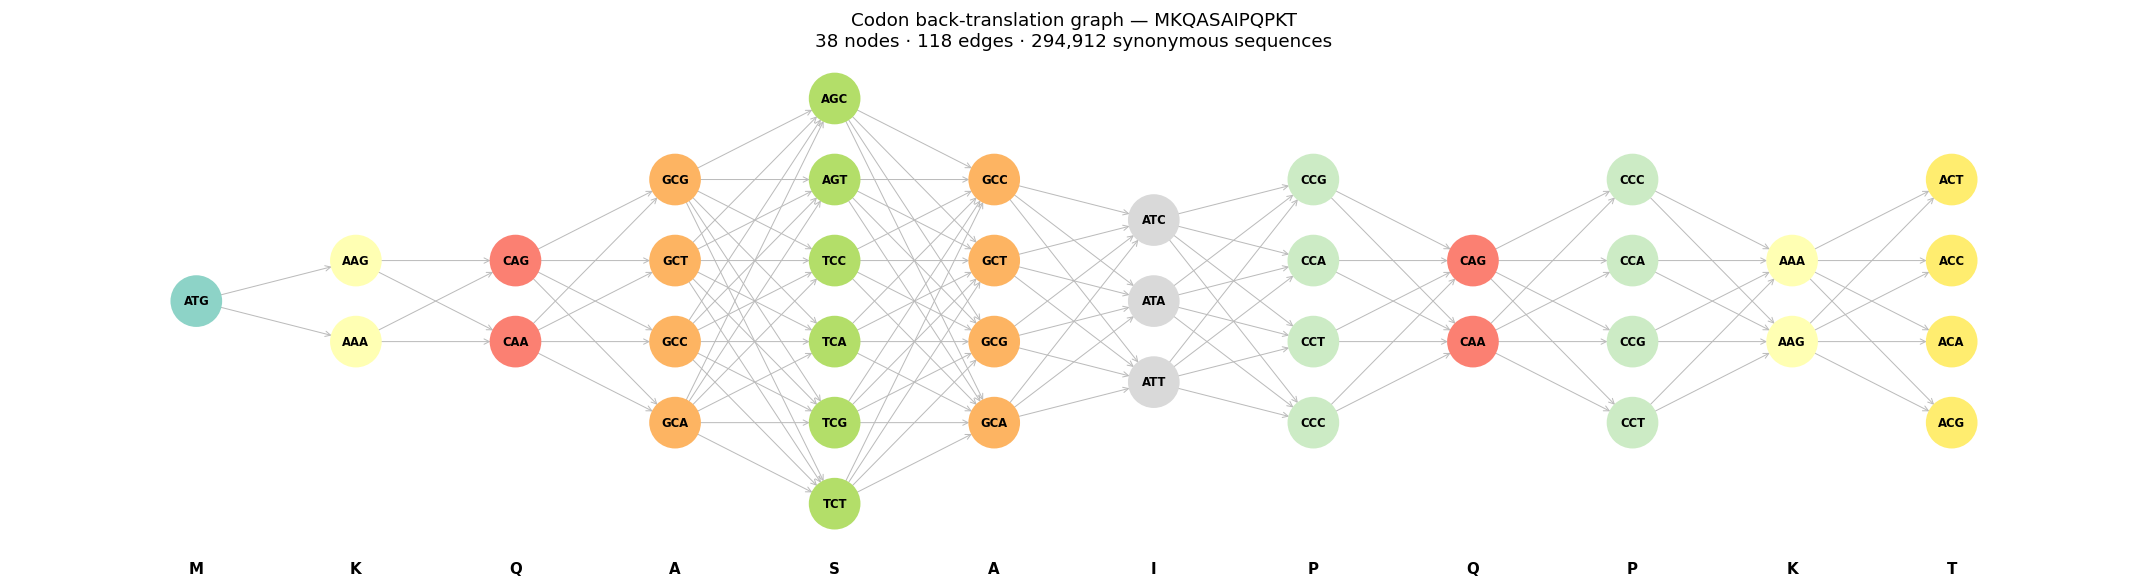

In [11]:
codon_pos = nx.multipartite_layout(G_codon, subset_key='subset', align='vertical')

# Colour nodes by amino acid identity (consistent within a position)
unique_aas = list(dict.fromkeys(aa_seq))  # order-preserving dedup
aa_colour = {aa: plt.cm.Set3(i / max(1, len(unique_aas) - 1))
             for i, aa in enumerate(unique_aas)}
node_colours_codon = [
    aa_colour[G_codon.nodes[n]['aa']] for n in G_codon.nodes()
]
codon_labels = {n: n.sequence for n in G_codon.nodes()}

fig, ax = plt.subplots(figsize=(18, 5))
nx.draw(
    G_codon, pos=codon_pos, ax=ax,
    labels=codon_labels, node_color=node_colours_codon,
    node_size=900, font_size=7, font_weight='bold',
    arrows=True, arrowstyle='->', arrowsize=8,
    edge_color='#bbbbbb', width=0.6,
)
ax.set_title(
    f"Codon back-translation graph — {aa_seq}\n"
    f"{G_codon.number_of_nodes()} nodes · "
    f"{G_codon.number_of_edges()} edges · "
    f"{total_synonymous:,} synonymous sequences",
    fontsize=11,
)

# Annotate each column with the amino acid letter.
# Compute mean x for each domain position from the layout dictionary.
col_x: dict[int, list[float]] = {}
for node, (x, _y) in codon_pos.items():
    col_x.setdefault(G_codon.nodes[node]['pos'], []).append(x)
col_x_mean = {p: np.mean(xs) for p, xs in col_x.items()}

all_ys = [y for _x, y in codon_pos.values()]
y_label = min(all_ys) - 0.12
for i, aa in enumerate(aa_seq):
    ax.text(
        col_x_mean[i], y_label,
        aa, ha='center', va='top', fontsize=9, fontweight='bold',
    )

plt.tight_layout()
plt.show()


## 8. Import the codon graph into Gen

`create_block_group_from_graph` accepts any `nx.DiGraph` with `Block` node keys.
The codon graph has no explicit `StartBlock`/`EndBlock` — Gen adds them automatically.
The resulting block group encodes every synonymous DNA sequence as a distinct path.

In [12]:
bg_codon = repo.create_block_group_from_graph(G_codon, name='codon_design')
print("Imported codon block group:", bg_codon)

# Verify round-trip: node count must match exactly.
# Edge count = original edges + sentinel connections
#   (StartBlock → every first-position codon) + (every last-position codon → EndBlock).
G_rt = bg_codon.to_networkx()
rt_content = content_nodes(G_rt)
n_first = len(pos_nodes[0])
n_last  = len(pos_nodes[-1])
expected_edges = G_codon.number_of_edges() + n_first + n_last
print(f"Round-trip content nodes: {len(rt_content)} (expected {G_codon.number_of_nodes()})")
print(f"Round-trip edges        : {G_rt.number_of_edges()} "
      f"(expected {expected_edges} = {G_codon.number_of_edges()} + {n_first} start + {n_last} end)")


Imported codon block group: BlockGroup(1673b0dbadf69ea1e8deecb8b7bdbd59fec012b70d8d640428304324cbbb371b, default, reference, codon_design)
Round-trip content nodes: 38 (expected 38)
Round-trip edges        : 123 (expected 123 = 118 + 1 start + 4 end)


In [13]:
bg_codon.plot()

## 9. Full shuffling-library back-translation

Every segment in the protein graph can be independently back-translated;
the segment-level topology is then preserved in DNA space.  The recipe:

1. For each protein segment block, build a chain of codon layers (one layer per
   amino acid, one node per synonymous codon — identical logic to section 5).
2. Within each segment chain, connect consecutive layers all-to-all.
3. Between segments, mirror every edge in the protein graph: connect the last
   codon layer of the source segment to the first codon layer of the target segment,
   again all-to-all.

The result is a compact DAG that implicitly encodes an astronomical number of
synonymous DNA sequences — one per path — without materialising any of them.

In [14]:
# Build per-segment codon chains.
# Fresh Block() at every position → unique UUID-7 per codon node; no cycles.
segment_codon_layers: dict = {}  # protein_block -> list[list[Block]]
for seg_node in content_nodes(G):
    seq = seg_node.sequence or ''
    layers = [
        [Block(codon) for codon in CODON_TABLE.get(aa, ['NNN'])]
        for aa in seq
    ]
    segment_codon_layers[seg_node] = layers

# Map each segment to its domain position index.
seg_domain: dict = {}
for d, layer in enumerate(content_gens):
    for seg in layer:
        seg_domain[seg] = d

G_lib_dna = nx.DiGraph()

# --- register all codon nodes ---
for seg_node, layers in segment_codon_layers.items():
    d = seg_domain[seg_node]
    for within_pos, layer in enumerate(layers):
        for block in layer:
            G_lib_dna.add_node(block, domain=d, within=within_pos)

# --- within-segment all-to-all edges ---
for seg_node, layers in segment_codon_layers.items():
    for i in range(len(layers) - 1):
        for src in layers[i]:
            for dst in layers[i + 1]:
                G_lib_dna.add_edge(src, dst)

# --- between-segment edges: mirror the protein graph topology ---
# Guard with `in segment_codon_layers` — the graph may contain zero-length
# boundary blocks that are neither content nodes nor StartBlock/EndBlock instances.
for seg_a, seg_b in G.edges():
    if seg_a not in segment_codon_layers or seg_b not in segment_codon_layers:
        continue
    for src in segment_codon_layers[seg_a][-1]:  # last codon layer of seg_a
        for dst in segment_codon_layers[seg_b][0]:  # first codon layer of seg_b
            G_lib_dna.add_edge(src, dst)

n_nodes = G_lib_dna.number_of_nodes()
n_edges = G_lib_dna.number_of_edges()
print(f"Full library DNA graph  : {n_nodes:,} nodes, {n_edges:,} edges")
print(f"Is DAG                  : {nx.is_directed_acyclic_graph(G_lib_dna)}")


Full library DNA graph  : 10,988 nodes, 38,308 edges
Is DAG                  : True


In [15]:
out_deg = [d for _, d in G_lib_dna.out_degree()]
in_deg  = [d for _, d in G_lib_dna.in_degree()]
print(f"Out-degree — min {min(out_deg)}, max {max(out_deg)}, mean {np.mean(out_deg):.2f}")
print(f"In-degree  — min {min(in_deg)},  max {max(in_deg)},  mean {np.mean(in_deg):.2f}")
print()

longest_dna = nx.dag_longest_path(G_lib_dna)
print(f"Longest path: {len(longest_dna)} codon nodes = {len(longest_dna) * 3} nt")
print()

# Use log10 sum to avoid integer overflow on the astronomically large product.
longest_aa = "".join(
    seg_node.sequence or ''
    for seg_node in nx.dag_longest_path(G)
    if seg_node in segment_codon_layers and seg_node.sequence
)
log10_single = sum(
    math.log10(len(CODON_TABLE.get(aa, ['NNN']))) for aa in longest_aa
)
print(f"Synonymous sequences for one chimera ({len(longest_aa)} aa): ~10^{log10_single:.0f}")
print(f"Library-wide total (6,561 chimeras): >> 10^{log10_single:.0f} (lower bound)")


Out-degree — min 0, max 12, mean 3.49
In-degree  — min 0,  max 18,  mean 3.49

Longest path: 1061 codon nodes = 3183 nt

Synonymous sequences for one chimera (1054 aa): ~10^517
Library-wide total (6,561 chimeras): >> 10^517 (lower bound)


### Structural plot

With tens of thousands of nodes a node-per-node label plot is impractical.
Instead we use a layout where **x maps to domain position** and **y spreads
codon variants within each domain**, giving a clear picture of the combinatorial
branching structure.  Each vertical column is one protein domain; within a column
the three segment variants appear as three parallel ribbons of codon nodes.

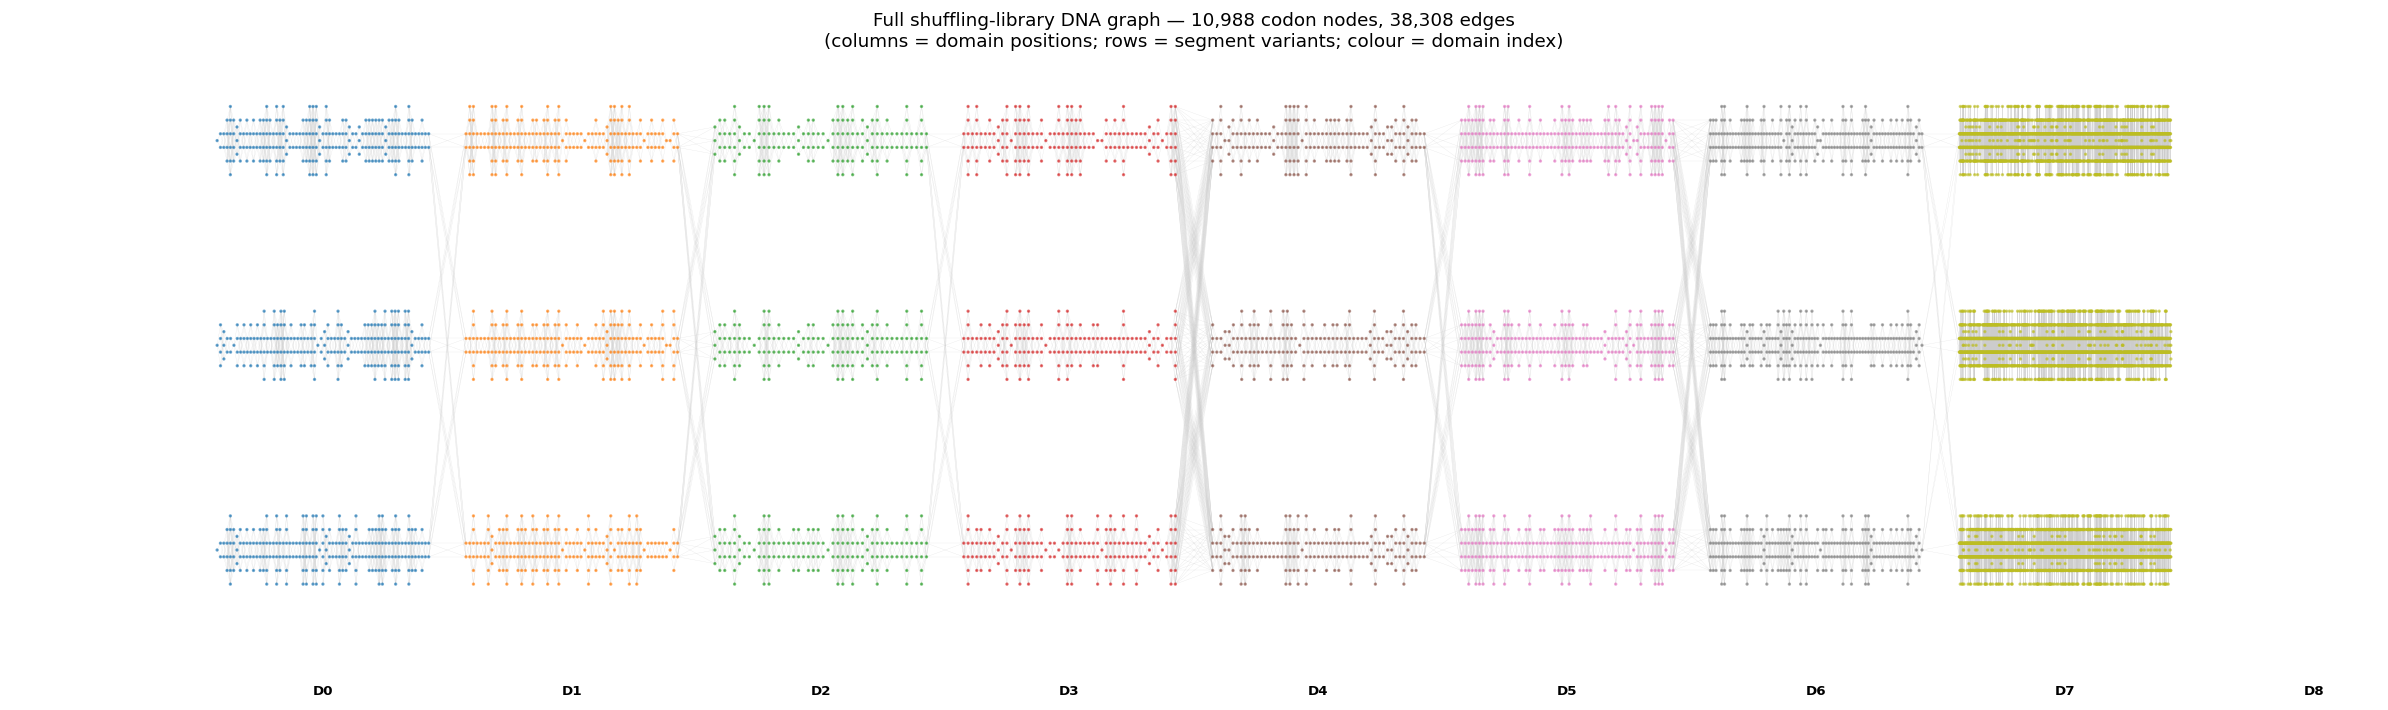

In [16]:
# Build a custom layout:
#   x = domain * x_scale + (within_pos / max_within) * (x_scale - gap)
#   y = variant_index within domain, spaced by y_scale

# Pre-compute: which variant (0/1/2) each segment is within its domain
seg_variant: dict = {}
for d, layer in enumerate(content_gens):
    for v, seg in enumerate(layer):
        seg_variant[seg] = v

n_domains = len(content_gens)
n_variants = max(len(layer) for layer in content_gens)
x_scale = 4.0   # horizontal distance between domain centres
y_scale = 1.2   # vertical separation between variants

pos_lib: dict = {}
for seg_node, layers in segment_codon_layers.items():
    d = seg_domain[seg_node]
    v = seg_variant[seg_node]
    max_within = max(1, len(layers) - 1)
    y_centre = (v - (n_variants - 1) / 2) * y_scale
    for within_pos, layer in enumerate(layers):
        x = d * x_scale + (within_pos / max_within) * (x_scale * 0.85)
        for j, block in enumerate(layer):
            # spread codon variants slightly in y within each layer
            y = y_centre + (j - (len(layer) - 1) / 2) * 0.08
            pos_lib[block] = (x, y)

node_colour_lib = [
    plt.cm.tab10(G_lib_dna.nodes[n]['domain'] / max(1, n_domains - 1))
    for n in G_lib_dna.nodes()
]

fig, ax = plt.subplots(figsize=(20, 6))
nx.draw(
    G_lib_dna, pos=pos_lib, ax=ax,
    node_color=node_colour_lib,
    node_size=1,
    with_labels=False,
    arrows=False,
    edge_color='#cccccc',
    width=0.15,
    alpha=0.6,
)

# Domain labels
for d in range(n_domains):
    x_mid = d * x_scale + 0.85 * x_scale / 2
    ax.text(x_mid, -(n_variants / 2) * y_scale - 0.25,
            f"D{d}", ha='center', fontsize=8, fontweight='bold')

ax.set_title(
    f"Full shuffling-library DNA graph — {n_nodes:,} codon nodes, {n_edges:,} edges\n"
    "(columns = domain positions; rows = segment variants; colour = domain index)",
    fontsize=11,
)
plt.tight_layout()
plt.show()


### Import into Gen

In [17]:
bg_lib_dna = repo.create_block_group_from_graph(G_lib_dna, name='library_dna')
print("Imported:", bg_lib_dna)

G_rt_lib = bg_lib_dna.to_networkx()
print(f"Round-trip: {len(content_nodes(G_rt_lib)):,} content nodes, "
      f"{G_rt_lib.number_of_edges():,} edges")


Imported: BlockGroup(edd7aa28094ad731cf45077738e8901a4ffe58fddb4915ac6f6f290ada6c4d8b, default, reference, library_dna)
Round-trip: 10,988 content nodes, 38,319 edges


In [18]:
bg_lib_dna.plot()
